In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, from_json
from pyspark.sql.types import StructType, StructField, StringType, FloatType, IntegerType, BooleanType, ArrayType

# Initialize Spark session
spark = SparkSession.builder \
            .appName("SentimentalAnalysisSpark") \
            .config("spark.driver.memory", "8g") \
            .getOrCreate()


# Access the SparkContext from the Spark session
sc = spark.sparkContext

# Define schema
schema = StructType([
    StructField("parent_asin", StringType(), True),
    StructField("main_category", StringType(), True),
    StructField("timestamp", StringType(), True),
    StructField("text", StringType(), True)
])

# Read the file as text (each line is a key-value pair)
file_path = "output_Sentiment_Analysis/part-r-00000"

# Each line in the file is assumed to be tab-separated
raw_df = spark.read.text(file_path)

# Split the raw data based on tab and assign to columns
df = raw_df.withColumn("parent_asin", split(col("value"), "\t").getItem(0)) \
           .withColumn("main_category", split(col("value"), "\t").getItem(1)) \
           .withColumn("timestamp", split(col("value"), "\t").getItem(2).cast(StringType())) \
           .withColumn("text", split(col("value"), "\t").getItem(3)) \
           .select("parent_asin", "main_category", "timestamp", "text")

# # Select individual columns from the parsed JSON
df.show(10, False)


+-----------+-------------+-------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|parent_asin|main_category|timestamp    |text                                                                                                                                                                                                                                                                                                                                         

In [2]:
from pyspark.sql.functions import col, from_unixtime, year, month

# Convert timestamp from Unix time (in milliseconds) to a proper timestamp and extract the year and month
df_with_year_month = df.withColumn("year", year(from_unixtime(col("timestamp") / 1000))) \
                       .withColumn("month", month(from_unixtime(col("timestamp") / 1000)))

# Select relevant columns including year and month
df_with_year_month = df_with_year_month.select("parent_asin", "main_category", "year", "month", "text")

# Show the DataFrame with year and month
df_with_year_month.show(10, False)

+-----------+-------------+----+-----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|parent_asin|main_category|year|month|text                                                                                                                                                                                                                                                                                                                                               

In [3]:
import nltk
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')

# Define a function to tokenize the text into words
def word_tokenize_text(text):
    tokens = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return tokens

# Apply the function to the DataFrame (assuming df_with_year_month is already available)
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType

# Define a UDF to apply tokenization
tokenize_udf = udf(word_tokenize_text, ArrayType(StringType()))

# Add a new column with tokenized words
df_with_tokens = df_with_year_month.withColumn("tokens", tokenize_udf(df_with_year_month["text"]))

# Show the tokenized DataFrame
df_with_tokens.select("parent_asin", "main_category", "year", "month", "tokens").show(truncate=False)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


+-----------+-------------+----+-----+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|parent_asin|main_category|year|month|tokens                                                                                                                                                                   

In [4]:
import nltk
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType

# Download necessary NLTK resources
nltk.download('punkt')

# Load stop words from a file (assuming each stop word is on a new line)
def load_stopwords(file_path):
    with open(file_path, "r") as file:
        stopwords = set(file.read().splitlines())  # Read and split by lines
    return stopwords

# Specify the path to your stopwords.txt file
stopwords_path = "stopwords-en.txt"

# Load the stopwords
stop_words = load_stopwords(stopwords_path)

# Broadcast the stop words to all workers
stop_words_broadcast = sc.broadcast(stop_words)

# Define a function to tokenize the text into words
def word_tokenize_text(text):
    tokens = nltk.word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return tokens

# Register the UDF for tokenization
tokenize_udf = udf(word_tokenize_text, ArrayType(StringType()))

# Apply tokenization to your DataFrame
df_with_tokens = df_with_year_month.withColumn("tokens", tokenize_udf(df_with_year_month["text"]))

# Define a UDF to remove stopwords using the broadcasted stop words
def remove_stopwords(tokens):
    return [word for word in tokens if word.isalnum() and word not in stop_words_broadcast.value]

# Register the UDF for removing stopwords
remove_stopwords_udf = udf(remove_stopwords, ArrayType(StringType()))

# Apply the UDF to your DataFrame
df_without_stopwords = df_with_tokens.withColumn("filtered_tokens", remove_stopwords_udf(df_with_tokens["tokens"]))

# Show the DataFrame with stop words removed
df_without_stopwords.select("parent_asin", "main_category", "year", "month", "filtered_tokens").show(truncate=False)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


+-----------+-------------+----+-----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|parent_asin|main_category|year|month|filtered_tokens                                                                                                                                                                                                                 |
+-----------+-------------+----+-----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|0007922582 |Video Games  |2018|4    |[dimensions, listed, photo, scale, tiny, print, difficult, read, black, dark, background, lights, bedtime, eyes, stars, book, shape, shipping, fast, stories, disappointed

In [5]:
from nltk.stem import WordNetLemmatizer

# Download the NLTK WordNet resource
nltk.download('wordnet')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to lemmatize the tokens
def lemmatize_tokens(tokens):
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize each word
    return lemmatized_tokens

# Register the UDF for lemmatizing
lemmatize_udf = udf(lemmatize_tokens, ArrayType(StringType()))

# Apply the function to the DataFrame
df_lemmatized = df_without_stopwords.withColumn("lemmatized_tokens", lemmatize_udf(df_without_stopwords["filtered_tokens"]))

# Show the DataFrame with lemmatized tokens
df_lemmatized.select("parent_asin", "main_category", "year", "month", "lemmatized_tokens").show(truncate=False)

[nltk_data] Downloading package wordnet to /root/nltk_data...


+-----------+-------------+----+-----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|parent_asin|main_category|year|month|lemmatized_tokens                                                                                                                                                                                                        |
+-----------+-------------+----+-----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|0007922582 |Video Games  |2018|4    |[dimension, listed, photo, scale, tiny, print, difficult, read, black, dark, background, light, bedtime, eye, star, book, shape, shipping, fast, story, disappointed, actual, product, dimensio

In [6]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.6 MB/s eta 0:00:00


In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyspark.sql.functions import udf

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Define a UDF (User Defined Function) to analyze sentiment
def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score['compound']
    # return compound
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

# Register the UDF in Spark
sentiment_udf = udf(get_sentiment, StringType())

In [8]:
# Apply the UDF to the DataFrame
df_sentiment = df_lemmatized.withColumn("sentiment", sentiment_udf(df_lemmatized["text"]))

# Show the results
df_sentiment.select("parent_asin", "main_category", "year", "month", "lemmatized_tokens", "sentiment").show(truncate=False)

+-----------+-------------+----+-----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|parent_asin|main_category|year|month|lemmatized_tokens                                                                                                                                                                                                        |sentiment|
+-----------+-------------+----+-----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|0007922582 |Video Games  |2018|4    |[dimension, listed, photo, scale, tiny, print, difficult, read, black, dark, background, light, bedtime, eye, star, book, shape, shipping, fast, story, disappoin

In [15]:
df_shorten = df_sentiment.select("parent_asin", "main_category", "year", "lemmatized_tokens", "sentiment")

df_shorten.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- lemmatized_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- sentiment: string (nullable = true)



In [16]:
df_shorten.show(10, False)

+-----------+-------------+----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|parent_asin|main_category|year|lemmatized_tokens                                                                                                                                                                                                     |sentiment|
+-----------+-------------+----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|0007922582 |Video Games  |2018|[dimension, listed, photo, scale, tiny, print, difficult, read, black, dark, background, light, bedtime, eye, star, book, shape, shipping, fast, story, disappointed, actual, product, dimension, 

In [24]:
from pyspark.sql.functions import udf, col, count, collect_list
from pyspark.sql.types import MapType, StringType, IntegerType
from collections import Counter

# Define a UDF to create a word frequency dictionary from a list of lemmatized tokens
def word_freq_dict(tokens):
    return dict(Counter(tokens))

# Register the UDF
word_freq_udf = udf(word_freq_dict, MapType(StringType(), IntegerType()))

# Create a DataFrame with word frequency for each row
df_with_word_freq = df_shorten.withColumn("word_freq", word_freq_udf(col("lemmatized_tokens")))

# Group by 'main_category', 'year', and 'sentiment' and aggregate the word frequencies
df_grouped = df_with_word_freq.groupBy("main_category", "year", "sentiment") \
    .agg(
        collect_list("word_freq").alias("word_freq_list"),
        count("*").alias("sentiment_count")  # Count the number of reviews per sentiment
    )

# Define a function to merge multiple word frequency dictionaries
def merge_dicts(dict_list):
    result = Counter()
    for d in dict_list:
        result.update(d)
    return dict(result)

# Register UDF to merge dictionaries
merge_dicts_udf = udf(merge_dicts, MapType(StringType(), IntegerType()))

# Apply the UDF to merge word frequency dictionaries within each group
df_final = df_grouped.withColumn("merged_word_freq", merge_dicts_udf(col("word_freq_list")))


In [25]:
# Select the final columns in the required format
df_final_result = df_final.select(
    "main_category",
    "year",
    "sentiment",
    "merged_word_freq",
    "sentiment_count"
)

# Show the final result
df_final_result.show(10, False)

+---------------+----+---------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [26]:
from pyspark.sql.functions import udf
from pyspark.sql.types import MapType, StringType, IntegerType
from collections import Counter

# Define a UDF to take the top 25 words by frequency from the merged_word_freq dictionary
def top_25_words(word_freq_dict):
    # Sort the dictionary by frequency in descending order and take the top 25
    top_25 = dict(Counter(word_freq_dict).most_common(25))
    return top_25

# Register the UDF
top_25_words_udf = udf(top_25_words, MapType(StringType(), IntegerType()))

# Apply the UDF to extract the top 25 words from the merged_word_freq column
df_top_25 = df_final_result.withColumn("top_25_words", top_25_words_udf(col("merged_word_freq")))

# Show the result
df_merged_25 = df_top_25.select("main_category", "year", "sentiment", "top_25_words", "sentiment_count")

df_merged_25.show(10, False)


+---------------+----+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------+
|main_category  |year|sentiment|top_25_words                                                                                                                                                                                                                                                                                                                                             |sentiment_count|
+---------------+----+---------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [27]:
df_merged_25.printSchema()

root
 |-- main_category: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- top_25_words: map (nullable = true)
 |    |-- key: string
 |    |-- value: integer (valueContainsNull = true)
 |-- sentiment_count: long (nullable = false)



In [30]:
from pyspark.sql import functions as F

# Convert the top_25_words map to a string (JSON format) to store in the CSV
df_flattened = df_merged_25.withColumn(
    "top_25_words", F.to_json("top_25_words")
)

# Write to a single CSV file
df_flattened.coalesce(1).write.csv("SentimentAnalysis", header=False, mode="overwrite")

In [29]:
df_flattened.show(10, False)

+---------------+----+---------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------+
|main_category  |year|sentiment|top_25_words                                                                                                                                                                                                                                                                                            |sentiment_count|
+---------------+----+---------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
from pyspark.sql import functions as F

# Create a formatted string from the map where each "key: value" pair is enclosed in quotes
df_flattened = df_merged_25.withColumn(
    "top_25_words",
    F.concat(
        F.lit("{"),
        F.concat_ws(", ", *[
            F.concat(F.lit('\"'), F.col("top_25_words").getItem(k).cast("string"), F.lit('\"'), F.lit(": "), F.col("top_25_words").getItem(k).cast("string"))
            for k in df_merged_25.columns if k != "top_25_words"
        ]),
        F.lit("}")
    )
)

# Write the DataFrame to a single CSV file with the header
df_flattened.coalesce(1).write.option("header", "true").csv("SentimentAnalysis", mode="overwrite")


In [2]:
import pandas as pd
import csv

# Load the CSV file with escapechar to handle commas inside the JSON text
df = pd.read_csv('../SentimentAnalysis2.csv', header=None, escapechar='\\')

# Rename the columns
df.columns = ['main_category', 'year', 'sentiment', 'word_freq', 'sentiment_count']

# Display the DataFrame to check
print(df.head())
print(df.shape)

     main_category  year sentiment  \
0  All Electronics  1999  negative   
1  All Electronics  1999  positive   
2  All Electronics  2000  positive   
3  All Electronics  2001  positive   
4  All Electronics  2002  negative   

                                           word_freq  sentiment_count  
0  {"product":1,"racing":1,"wheel":1,"hp":1,"inte...                1  
1  {"plane":1,"game":2,"software":2,"falcon":2,"p...                4  
2  {"flight":7,"game":39,"software":8,"thumb":7,"...               32  
3  {"play":19,"game":121,"color":12,"software":14...               44  
4  {"play":2,"game":4,"feel":3,"depress":2,"fight...                6  
(541, 5)


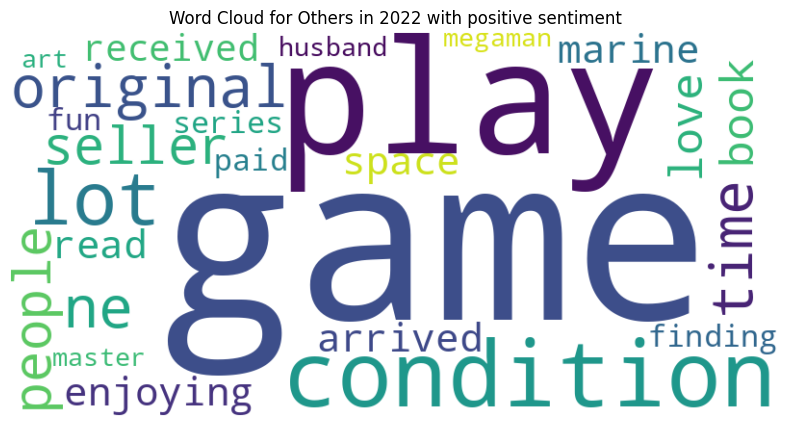

In [6]:
import json
from wordcloud import WordCloud
import matplotlib.pyplot as plt

main_category = 'Others'
year = 2022
sentiment = 'positive'

# Filter the DataFrame based on specific criteria
filtered_df = df[(df['main_category'] == main_category) &
                 (df['year'] == year) &
                 (df['sentiment'] == sentiment)]

# Combine all word frequencies into a single dictionary
combined_word_freq = {}
for freq_str in filtered_df['word_freq']:
    # Convert the JSON string to a dictionary
    freq_dict = json.loads(freq_str)
    for word, count in freq_dict.items():
        if word in combined_word_freq:
            combined_word_freq[word] += count  # Add up the counts if word is repeated
        else:
            combined_word_freq[word] = count

# Create the word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(combined_word_freq)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.title(f"Word Cloud for {main_category} in {year} with {sentiment} sentiment")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


Positive Sentiment Count: 95602
Negative Sentiment Count: 14472
Neutral Sentiment Count: 7295


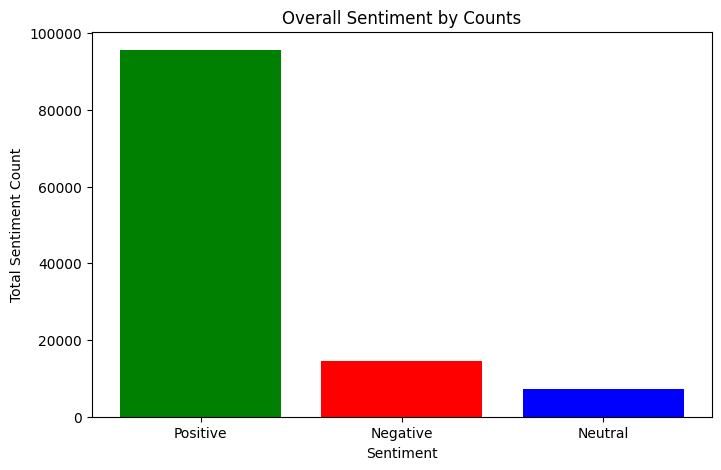

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the sentiment count variables
pos_count = 0
neg_count = 0
neu_count = 0

# Calculate sentiment_count sums based on sentiment
pos_count = df[df['sentiment'] == 'positive']['sentiment_count'].sum()
neg_count = df[df['sentiment'] == 'negative']['sentiment_count'].sum()
neu_count = df[df['sentiment'] == 'neutral']['sentiment_count'].sum()

# Display the results
print(f"Positive Sentiment Count: {pos_count}")
print(f"Negative Sentiment Count: {neg_count}")
print(f"Neutral Sentiment Count: {neu_count}")

# Plotting the sentiment counts
sentiment_labels = ['Positive', 'Negative', 'Neutral']
sentiment_values = [pos_count, neg_count, neu_count]

plt.figure(figsize=(8, 5))
plt.bar(sentiment_labels, sentiment_values, color=['green', 'red', 'blue'])
plt.title('Overall Sentiment by Counts')
plt.xlabel('Sentiment')
plt.ylabel('Total Sentiment Count')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by year and sentiment, summing sentiment_count
sentiment_by_year = df.groupby(['year', 'sentiment'])['sentiment_count'].sum().unstack()
print(sentiment_by_year)

# Plotting the data as a stacked bar chart
sentiment_by_year.plot(kind='bar', stacked=True, figsize=(10, 6), color=['pink', 'red', 'green'])

# Title and labels
plt.title('Sentiment Distribution Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Sentiment Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()